In [6]:
import os
import random
import numpy as np
import tensorflow as tf

# For dataset
import glob
from PIL import Image

# For models
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.optimizers.legacy import Adam
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.layers import (Conv2D, Dense, Flatten, Reshape, LeakyReLU,
                                     Dropout, Embedding, Input, Concatenate,
                                     Conv2DTranspose, UpSampling2D, BatchNormalization,
                                     LeakyReLU, Add)

# For callback
from tensorflow.keras.preprocessing.image import array_to_img
from tensorflow.keras.callbacks import Callback

# For streamlining ML workflow
import wandb
import math
import matplotlib.pyplot as plt

# Requires TensorFlow >=2.11 for the GroupNormalization layer.
from tensorflow import keras
from tensorflow.keras import layers

# For model memory usage
from tensorflow.keras import backend as K
import humanize

import time

num_epochs       = 100
total_timesteps  = 1000
norm_groups      = 8
learning_rate    = 1e-4
batch_size       = 16
img_size         = 128
img_channels     = 3

# =========================
# LDM Settings
# =========================
# VAE compresses 128x128x3  ->  32x32x4  (4x spatial, not 8x)
# Keeping more spatial resolution = sharper reconstructions = better KID
latent_size      = 32    # FIX 1: 32 not 16 — retains more spatial detail
latent_channels  = 4
# FIX 2: KL weight raised from 1e-6 to 1e-4 so latents are actually Gaussian-shaped
kl_weight        = 1e-4
# FIX 3: Latent scale factor — normalise latents to ~unit std before diffusion
# (mirrors Stable Diffusion's 0.18215 scaling; we learn it empirically or fix to 0.5)
LATENT_SCALE     = 0.5

# =========================
# 1) Data set Settings
# =========================
DATA_DIR  = '/kaggle/input/datasets/imrankhan77/nct-crc-he-100k/NCT-CRC-HE-100K'
VALID_EXT = {".tif"}

# =========================
# 2) Get class names
# =========================
class_names = sorted([
    d for d in os.listdir(DATA_DIR)
    if os.path.isdir(os.path.join(DATA_DIR, d)) and d.upper() == "NORM"
])
print("Classes:", class_names)
print("Number of classes:", len(class_names))
class_to_label = {name: i for i, name in enumerate(class_names)}

# =========================
# 3) Collect image paths
# =========================
file_paths, labels = [], []
for cls in class_names:
    cls_path  = os.path.join(DATA_DIR, cls)
    all_files = glob.glob(os.path.join(cls_path, "*"))
    all_files = [fp for fp in all_files if os.path.splitext(fp)[1].lower() in VALID_EXT]
    random.shuffle(all_files)
    selected  = all_files[:]
    file_paths.extend(selected)
    labels.extend([class_to_label[cls]] * len(selected))
    print(f"{cls}: selected {len(selected)} files")
print("\nTotal selected images:", len(file_paths))

file_paths = tf.constant(file_paths)
labels     = tf.constant(labels, dtype=tf.int32)

# =========================
# 4) Image loading + normalize to [-1,1]
# =========================
def pil_load(path_bytes):
    path = path_bytes.decode("utf-8") if isinstance(path_bytes, (bytes, bytearray)) else str(path_bytes)
    img  = Image.open(path).convert("RGB")
    img  = img.resize((img_size, img_size))
    arr  = np.asarray(img, dtype=np.float32)
    arr  = (arr / 127.5) - 1.0
    return arr

def load_image(path, label):
    img = tf.numpy_function(pil_load, [path], tf.float32)
    img.set_shape([img_size, img_size, 3])
    return img, label

# =========================
# 5) Build tf.data pipeline
# =========================
dataset = tf.data.Dataset.from_tensor_slices((file_paths, labels))
dataset = dataset.shuffle(buffer_size=len(file_paths), reshuffle_each_iteration=True)
dataset = dataset.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
dataset = dataset.batch(batch_size, drop_remainder=True)
dataset = dataset.repeat()
dataset = dataset.prefetch(tf.data.AUTOTUNE)
print("\nDataset ready ✅")

# ============================================================
# VAE — Encoder + Decoder
# FIX: Added ResBlocks to encoder/decoder for much sharper reconstructions
# FIX: 32x32 latents instead of 16x16 (only 2x downsampling per side less)
# FIX: Perceptual-style loss (L1 + SSIM) instead of pure L1
# ============================================================

def res_block_vae(x, filters, groups=8):
    """Lightweight residual block for the VAE."""
    residual = x if x.shape[-1] == filters else layers.Conv2D(filters, 1, padding="same")(x)
    x = layers.GroupNormalization(groups=groups)(x)
    x = layers.Activation("swish")(x)
    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.GroupNormalization(groups=groups)(x)
    x = layers.Activation("swish")(x)
    x = layers.Conv2D(filters, 3, padding="same")(x)
    return layers.Add()([x, residual])


def build_encoder(img_size=128, img_channels=3, latent_channels=4):
    """
    128x128x3  ->  32x32x(2*latent_channels)
    Two strided downsamples (2x each) + residual refinement.
    """
    inp = layers.Input(shape=(img_size, img_size, img_channels), name="encoder_input")
    x   = layers.Conv2D(128, 3, padding="same")(inp)                               # 128x128x128

    # Down 1: 128 -> 64
    x = res_block_vae(x, 128)
    x = res_block_vae(x, 128)
    x = layers.Conv2D(128, 3, strides=2, padding="same")(x)                       # 64x64x128

    # Down 2: 64 -> 32
    x = res_block_vae(x, 256)
    x = res_block_vae(x, 256)
    x = layers.Conv2D(256, 3, strides=2, padding="same")(x)                       # 32x32x256

    # Bottleneck residual + attention
    x = res_block_vae(x, 256)
    x = layers.GroupNormalization(groups=norm_groups)(x)
    x = layers.Activation("swish")(x)

    # Project to latent params
    z_params = layers.Conv2D(latent_channels * 2, 1, padding="same")(x)           # 32x32x8
    return keras.Model(inp, z_params, name="encoder")


def build_decoder(latent_size=32, latent_channels=4, img_channels=3):
    """
    32x32x4  ->  128x128x3
    Mirror of encoder with residual blocks.
    """
    inp = layers.Input(shape=(latent_size, latent_size, latent_channels), name="decoder_input")
    x   = layers.Conv2D(256, 3, padding="same")(inp)                              # 32x32x256

    x = res_block_vae(x, 256)
    x = layers.GroupNormalization(groups=norm_groups)(x)
    x = layers.Activation("swish")(x)

    # Up 1: 32 -> 64
    x = layers.UpSampling2D(2)(x)
    x = layers.Conv2D(256, 3, padding="same")(x)                                  # 64x64x256
    x = res_block_vae(x, 256)
    x = res_block_vae(x, 256)

    # Up 2: 64 -> 128
    x = layers.UpSampling2D(2)(x)
    x = layers.Conv2D(128, 3, padding="same")(x)                                  # 128x128x128
    x = res_block_vae(x, 128)
    x = res_block_vae(x, 128)

    x = layers.GroupNormalization(groups=norm_groups)(x)
    x = layers.Activation("swish")(x)
    out = layers.Conv2D(img_channels, 3, padding="same", activation="tanh")(x)   # 128x128x3
    return keras.Model(inp, out, name="decoder")


def sampling(z_params):
    """Reparameterisation trick."""
    mean, log_var = tf.split(z_params, num_or_size_splits=2, axis=-1)
    log_var = tf.clip_by_value(log_var, -30.0, 20.0)
    epsilon = tf.random.normal(shape=tf.shape(mean))
    return mean + tf.exp(0.5 * log_var) * epsilon, mean, log_var


def ssim_loss(y_true, y_pred):
    """1 - SSIM as an additional perceptual loss term."""
    y_true = (y_true + 1.0) / 2.0
    y_pred = (y_pred + 1.0) / 2.0
    return 1.0 - tf.reduce_mean(tf.image.ssim(y_true, y_pred, max_val=1.0))


class VAE(keras.Model):
    def __init__(self, encoder, decoder, kl_weight=1e-4):
        super().__init__()
        self.encoder   = encoder
        self.decoder   = decoder
        self.kl_weight = kl_weight

    def encode(self, x, training=False, use_mean=False):
        """
        FIX: use_mean=True at inference — use the deterministic mean latent,
        not a stochastic sample. Avoids noisy latents corrupting generation.
        """
        z_params = self.encoder(x, training=training)
        if use_mean:
            mean, _ = tf.split(z_params, num_or_size_splits=2, axis=-1)
            return mean, mean, tf.zeros_like(mean)
        z, mean, log_var = sampling(z_params)
        return z, mean, log_var

    def decode(self, z, training=False):
        return self.decoder(z, training=training)

    def call(self, x, training=False):
        z, mean, log_var = self.encode(x, training=training)
        x_recon = self.decode(z, training=training)
        return x_recon, mean, log_var

    def train_step(self, data):
        x = data[0] if isinstance(data, (tuple, list)) else data
        with tf.GradientTape() as tape:
            x_recon, mean, log_var = self(x, training=True)
            # FIX: Combined L1 + SSIM loss for sharper reconstructions
            l1_loss   = tf.reduce_mean(tf.abs(x - x_recon))
            perp_loss = ssim_loss(x, x_recon)
            recon_loss = l1_loss + 0.1 * perp_loss
            kl_loss    = -0.5 * tf.reduce_mean(1 + log_var - tf.square(mean) - tf.exp(log_var))
            loss = recon_loss + self.kl_weight * kl_loss
        grads = tape.gradient(loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        return {"loss": loss, "recon_loss": recon_loss, "kl_loss": kl_loss}

# =========================
# Architecture Settings (U-Net for latent diffusion)
# FIX: Only 3 U-Net levels for 32x32 latents — prevents over-downsampling
# 32 -> 16 -> 8 (stopping there, no further)
# =========================
first_conv_channels = 128                 # FIX: wider base (was 64) since latent space is richer
channel_multiplier  = [1, 2, 4]          # FIX: 3 levels only (was 4) — correct for 32x32 input
widths              = [first_conv_channels * m for m in channel_multiplier]  # [128, 256, 512]
has_attention       = [False, True, True] # FIX: attention at 16x16 and 8x8 (meaningful scales)
num_res_blocks      = 2

# =========================
# Diffusion Logic (identical — operates on scaled latents)
# =========================
class GaussianDiffusion:
    def __init__(self, timesteps=1000, clip_min=-1.0, clip_max=1.0):
        self.timesteps = timesteps
        self.clip_min  = clip_min
        self.clip_max  = clip_max

        def f(t, T):
            s = 0.008
            return np.cos((((t / T) + s) / (1 + s)) * (np.pi / 2)) ** 2

        t               = np.arange(timesteps + 1, dtype=np.float64)
        alphas_cumprod  = f(t, timesteps) / f(0, timesteps)
        betas           = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
        betas           = np.clip(betas, a_min=0, a_max=0.999)
        self.betas      = tf.constant(betas, dtype=tf.float32)
        alphas              = 1.0 - betas
        alphas_cumprod      = np.cumprod(alphas, axis=0)
        alphas_cumprod_prev = np.append(1.0, alphas_cumprod[:-1])

        self.num_timesteps       = int(timesteps)
        self.alphas_cumprod      = tf.constant(alphas_cumprod,      dtype=tf.float32)
        self.alphas_cumprod_prev = tf.constant(alphas_cumprod_prev, dtype=tf.float32)

        self.sqrt_alphas_cumprod           = tf.constant(np.sqrt(alphas_cumprod),        dtype=tf.float32)
        self.sqrt_one_minus_alphas_cumprod = tf.constant(np.sqrt(1.0 - alphas_cumprod),  dtype=tf.float32)
        self.log_one_minus_alphas_cumprod  = tf.constant(np.log(1.0 - alphas_cumprod),   dtype=tf.float32)
        self.sqrt_recip_alphas_cumprod     = tf.constant(np.sqrt(1.0 / alphas_cumprod),  dtype=tf.float32)
        self.sqrt_recipm1_alphas_cumprod   = tf.constant(np.sqrt(1.0 / alphas_cumprod - 1), dtype=tf.float32)

        posterior_variance = betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)
        self.posterior_variance             = tf.constant(posterior_variance, dtype=tf.float32)
        self.posterior_log_variance_clipped = tf.constant(
            np.log(np.maximum(posterior_variance, 1e-20)), dtype=tf.float32
        )
        self.posterior_mean_coef1 = tf.constant(
            betas * np.sqrt(alphas_cumprod_prev) / (1.0 - alphas_cumprod), dtype=tf.float32
        )
        self.posterior_mean_coef2 = tf.constant(
            (1.0 - alphas_cumprod_prev) * np.sqrt(alphas) / (1.0 - alphas_cumprod), dtype=tf.float32
        )
        self.snr = self.alphas_cumprod / (1.0 - self.alphas_cumprod)

    def _extract(self, a, t, x_shape):
        batch_size = x_shape[0]
        out = tf.gather(a, t)
        return tf.reshape(out, [batch_size, 1, 1, 1])

    def q_sample(self, x_start, t, noise):
        x_start_shape = tf.shape(x_start)
        return (
            self._extract(self.sqrt_alphas_cumprod, t, tf.shape(x_start)) * x_start
            + self._extract(self.sqrt_one_minus_alphas_cumprod, t, x_start_shape) * noise
        )

    def predict_start_from_noise(self, x_t, t, noise):
        x_t_shape = tf.shape(x_t)
        return (
            self._extract(self.sqrt_recip_alphas_cumprod, t, x_t_shape) * x_t
            - self._extract(self.sqrt_recipm1_alphas_cumprod, t, x_t_shape) * noise
        )

    def q_posterior(self, x_start, x_t, t):
        x_t_shape = tf.shape(x_t)
        posterior_mean = (
            self._extract(self.posterior_mean_coef1, t, x_t_shape) * x_start
            + self._extract(self.posterior_mean_coef2, t, x_t_shape) * x_t
        )
        posterior_variance             = self._extract(self.posterior_variance, t, x_t_shape)
        posterior_log_variance_clipped = self._extract(self.posterior_log_variance_clipped, t, x_t_shape)
        return posterior_mean, posterior_variance, posterior_log_variance_clipped

    def p_mean_variance(self, pred_noise, x, t, clip_denoised=True):
        x_recon = self.predict_start_from_noise(x, t=t, noise=pred_noise)
        if clip_denoised:
            x_recon = self.dynamic_thresholding(x_recon, p=0.995, c=1.0)
        model_mean, posterior_variance, posterior_log_variance = self.q_posterior(
            x_start=x_recon, x_t=x, t=t
        )
        return model_mean, posterior_variance, posterior_log_variance

    def p_sample(self, pred_noise, x, t, clip_denoised=True):
        model_mean, _, model_log_variance = self.p_mean_variance(
            pred_noise, x=x, t=t, clip_denoised=clip_denoised
        )
        noise        = tf.random.normal(shape=x.shape, dtype=x.dtype)
        nonzero_mask = tf.reshape(1 - tf.cast(tf.equal(t, 0), tf.float32), [tf.shape(x)[0], 1, 1, 1])
        return model_mean + nonzero_mask * tf.exp(0.5 * model_log_variance) * noise

    def dynamic_thresholding(self, x_recon, p=0.995, c=1.0):
        abs_x        = tf.abs(x_recon)
        batch_size   = tf.shape(abs_x)[0]
        abs_x_flat   = tf.reshape(abs_x, [batch_size, -1])
        sorted_x     = tf.sort(abs_x_flat, axis=-1)
        num_elements = tf.cast(tf.shape(sorted_x)[-1], tf.float32)
        percentile_index = tf.cast(num_elements * p, tf.int32)
        percentile_index = tf.clip_by_value(percentile_index, 0, tf.shape(sorted_x)[-1] - 1)
        s = tf.gather(sorted_x, percentile_index, axis=-1)
        s = tf.maximum(s, c)
        s = tf.reshape(s, [batch_size, 1, 1, 1])
        x_recon = tf.clip_by_value(x_recon, -s, s) / s
        return x_recon

# =========================
# U-Net Building Functions
# =========================
def kernel_init(scale):
    scale = max(scale, 1e-10)
    return keras.initializers.VarianceScaling(scale, mode="fan_avg", distribution="uniform")


class AttentionBlock(layers.Layer):
    def __init__(self, units, groups=8, **kwargs):
        self.units  = units
        self.groups = groups
        super().__init__(**kwargs)
        self.norm  = layers.GroupNormalization(groups=groups)
        self.query = layers.Dense(units, kernel_initializer=kernel_init(1.0))
        self.key   = layers.Dense(units, kernel_initializer=kernel_init(1.0))
        self.value = layers.Dense(units, kernel_initializer=kernel_init(1.0))
        self.proj  = layers.Dense(units, kernel_initializer=kernel_init(0.0))

    def call(self, inputs):
        batch_size = tf.shape(inputs)[0]
        height     = tf.shape(inputs)[1]
        width      = tf.shape(inputs)[2]
        scale      = tf.cast(self.units, tf.float32) ** (-0.5)
        inputs     = self.norm(inputs)
        q = self.query(inputs)
        k = self.key(inputs)
        v = self.value(inputs)
        attn_score = tf.einsum("bhwc, bHWc->bhwHW", q, k) * scale
        attn_score = tf.reshape(attn_score, [batch_size, height, width, height * width])
        attn_score = tf.nn.softmax(attn_score, -1)
        attn_score = tf.reshape(attn_score, [batch_size, height, width, height, width])
        proj = tf.einsum("bhwHW,bHWc->bhwc", attn_score, v)
        proj = self.proj(proj)
        return inputs + proj


class TimeEmbedding(layers.Layer):
    def __init__(self, dim, **kwargs):
        super().__init__(**kwargs)
        self.dim      = dim
        self.half_dim = dim // 2
        self.emb      = math.log(10000) / (self.half_dim - 1)
        self.emb      = tf.exp(tf.range(self.half_dim, dtype=tf.float32) * -self.emb)

    def call(self, inputs):
        inputs = tf.cast(inputs, dtype=tf.float32)
        emb    = inputs[:, None] * self.emb[None, :]
        emb    = tf.concat([tf.sin(emb), tf.cos(emb)], axis=-1)
        return emb


def ResidualBlock(width, groups=8, activation_fn=keras.activations.swish):
    def apply(inputs):
        x, t        = inputs
        input_width = x.shape[3]
        residual    = x if input_width == width else layers.Conv2D(
            width, kernel_size=1, kernel_initializer=kernel_init(1.0))(x)
        temb = activation_fn(t)
        temb = layers.Dense(width, kernel_initializer=kernel_init(1.0))(temb)[:, None, None, :]
        x = layers.GroupNormalization(groups=groups)(x)
        x = activation_fn(x)
        x = layers.Conv2D(width, kernel_size=3, padding="same", kernel_initializer=kernel_init(1.0))(x)
        x = layers.Add()([x, temb])
        x = layers.GroupNormalization(groups=groups)(x)
        x = activation_fn(x)
        x = layers.Conv2D(width, kernel_size=3, padding="same", kernel_initializer=kernel_init(0.0))(x)
        x = layers.Add()([x, residual])
        return x
    return apply


def DownSample(width):
    def apply(x):
        x = layers.Conv2D(width, kernel_size=3, strides=2, padding="same",
                          kernel_initializer=kernel_init(1.0))(x)
        return x
    return apply


def UpSample(width, interpolation="nearest"):
    def apply(x):
        x = layers.UpSampling2D(size=2, interpolation=interpolation)(x)
        x = layers.Conv2D(width, kernel_size=3, padding="same",
                          kernel_initializer=kernel_init(1.0))(x)
        return x
    return apply


def TimeMLP(units, activation_fn=keras.activations.swish):
    def apply(inputs):
        temb = layers.Dense(units, activation=activation_fn, kernel_initializer=kernel_init(1.0))(inputs)
        temb = layers.Dense(units, kernel_initializer=kernel_init(1.0))(temb)
        return temb
    return apply


def build_model(
    img_size, img_channels, widths, has_attention, first_conv_channels,
    num_res_blocks, norm_groups=8, interpolation="nearest",
    activation_fn=keras.activations.swish,
):
    image_input = layers.Input(shape=(img_size, img_size, img_channels), name="image_input")
    time_input  = keras.Input(shape=(), dtype=tf.int64, name="time_input")

    x = layers.Conv2D(first_conv_channels, kernel_size=(3, 3), padding="same",
                      kernel_initializer=kernel_init(1.0))(image_input)

    temb = TimeEmbedding(dim=first_conv_channels * 4)(time_input)
    temb = TimeMLP(units=first_conv_channels * 4, activation_fn=activation_fn)(temb)

    skips = [x]

    # DownBlock
    for i in range(len(widths)):
        for _ in range(num_res_blocks):
            x = ResidualBlock(widths[i], groups=norm_groups, activation_fn=activation_fn)([x, temb])
            if has_attention[i]:
                x = AttentionBlock(widths[i], groups=norm_groups)(x)
            skips.append(x)
        if widths[i] != widths[-1]:
            x = DownSample(widths[i])(x)
            skips.append(x)

    # MiddleBlock
    x = ResidualBlock(widths[-1], groups=norm_groups, activation_fn=activation_fn)([x, temb])
    x = AttentionBlock(widths[-1], groups=norm_groups)(x)
    x = ResidualBlock(widths[-1], groups=norm_groups, activation_fn=activation_fn)([x, temb])

    # UpBlock
    for i in reversed(range(len(widths))):
        for _ in range(num_res_blocks + 1):
            x = layers.Concatenate(axis=-1)([x, skips.pop()])
            x = ResidualBlock(widths[i], groups=norm_groups, activation_fn=activation_fn)([x, temb])
            if has_attention[i]:
                x = AttentionBlock(widths[i], groups=norm_groups)(x)
        if i != 0:
            x = UpSample(widths[i], interpolation=interpolation)(x)

    # End block
    x = layers.GroupNormalization(groups=norm_groups)(x)
    x = activation_fn(x)
    x = layers.Conv2D(img_channels, (3, 3), padding="same", kernel_initializer=kernel_init(0.0))(x)
    return keras.Model([image_input, time_input], x, name="unet_latent")

# ============================================================
# Latent Diffusion Model
# ============================================================
class LatentDiffusionModel(keras.Model):
    """
    LDM = frozen VAE encoder  +  DDPM denoiser on latents  +  VAE decoder.

    KEY FIXES vs v1:
    - encode() uses the mean latent (not a random sample) for stable training targets
    - Latents are scaled by LATENT_SCALE before diffusion, unscaled after
    - U-Net has 3 levels (not 4) matching the 32x32 latent resolution
    - Wider U-Net (128 base channels) to compensate for the larger latent space
    """
    def __init__(self, vae, network, ema_network, timesteps,
                 latent_size, latent_channels, gdf_util, latent_scale=0.5, ema=0.999):
        super().__init__()
        self.vae             = vae
        self.network         = network
        self.ema_network     = ema_network
        self.timesteps       = timesteps
        self.latent_size     = latent_size
        self.latent_channels = latent_channels
        self.gdf_util        = gdf_util
        self.latent_scale    = latent_scale
        self.ema             = ema

    def train_step(self, data):
        images     = data[0] if isinstance(data, (tuple, list)) else data
        batch_size = tf.shape(images)[0]

        # --- 1. Encode to latent space — use MEAN for stable training targets ---
        z_params = self.vae.encoder(images, training=False)
        mean, _  = tf.split(z_params, num_or_size_splits=2, axis=-1)
        # FIX: scale latents so they are ~unit variance for the diffusion process
        latents  = mean * self.latent_scale

        # --- 2. Sample timestep ---
        t = tf.random.uniform(minval=0, maxval=self.timesteps,
                              shape=(batch_size,), dtype=tf.int64)

        with tf.GradientTape() as tape:
            # --- 3. Offset noise ---
            noise = tf.random.normal(shape=tf.shape(latents), dtype=latents.dtype)
            offset_strength = 0.1
            offset_noise    = tf.random.normal(
                shape=(batch_size, 1, 1, self.latent_channels), dtype=latents.dtype
            )
            noise = noise + offset_strength * offset_noise

            # --- 4. Forward diffusion on scaled latents ---
            latents_t  = self.gdf_util.q_sample(latents, t, noise)
            pred_noise = self.network([latents_t, t], training=True)

            # --- 5. Min-SNR loss ---
            snr_t       = self.gdf_util._extract(self.gdf_util.snr, t, tf.shape(latents))
            gamma       = 5.0
            loss_weight = tf.minimum(gamma, snr_t) / snr_t
            mse         = tf.square(noise - pred_noise)
            loss        = tf.reduce_mean(loss_weight * mse)

        gradients = tape.gradient(loss, self.network.trainable_weights)
        self.optimizer.apply_gradients(zip(gradients, self.network.trainable_weights))

        for weight, ema_weight in zip(self.network.weights, self.ema_network.weights):
            ema_weight.assign(self.ema * ema_weight + (1 - self.ema) * weight)

        return {"loss": loss}

    def generate_images(self, num_images=16):
        """Reverse diffusion in scaled latent space, then decode."""
        samples = tf.random.normal(
            shape=(num_images, self.latent_size, self.latent_size, self.latent_channels),
            dtype=tf.float32
        )
        for t in reversed(range(0, self.timesteps)):
            tt         = tf.cast(tf.fill(num_images, t), dtype=tf.int64)
            pred_noise = self.ema_network.predict([samples, tt], verbose=0, batch_size=num_images)
            samples    = self.gdf_util.p_sample(pred_noise, samples, tt, clip_denoised=True)

        # FIX: unscale latents before decoding
        latents      = samples / self.latent_scale
        pixel_images = self.vae.decode(latents, training=False)
        return pixel_images


class ImageVisualizationCallback(keras.callbacks.Callback):
    def __init__(self, num_images=16, freq=10):
        super().__init__()
        self.num_images = num_images
        self.freq       = freq

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.freq == 0:
            print(f"\nGenerating images at the end of epoch {epoch + 1}...")
            generated_images = self.model.generate_images(num_images=self.num_images)
            generated_images = (generated_images + 1.0) / 2.0
            generated_images = np.clip(generated_images.numpy(), 0.0, 1.0)
            num_cols = 4
            num_rows = self.num_images // num_cols
            plt.figure(figsize=(num_cols * 3, num_rows * 3))
            for i in range(self.num_images):
                plt.subplot(num_rows, num_cols, i + 1)
                plt.imshow(generated_images[i])
                plt.axis("off")
            plt.suptitle(f"Generated Images at Epoch {epoch + 1}", fontsize=16)
            plt.tight_layout()
            plt.show()


class EMASaveCallback(keras.callbacks.Callback):
    def __init__(self, save_epochs, filepath_template="/kaggle/working/ldm_unet_epoch_{}.keras"):
        super().__init__()
        self.save_epochs       = save_epochs
        self.filepath_template = filepath_template

    def on_epoch_end(self, epoch, logs=None):
        current_epoch = epoch + 1
        if current_epoch in self.save_epochs:
            current_filepath = self.filepath_template.format(current_epoch)
            print(f"\n[INFO] Epoch {current_epoch}: Saving EMA U-Net to {current_filepath}...")
            self.model.ema_network.save(current_filepath)

# ============================================================
# Step 1 — Train VAE
# ============================================================
encoder = build_encoder(img_size=img_size, img_channels=img_channels, latent_channels=latent_channels)
decoder = build_decoder(latent_size=latent_size, latent_channels=latent_channels, img_channels=img_channels)

vae = VAE(encoder, decoder, kl_weight=kl_weight)
vae.compile(optimizer=keras.optimizers.Adam(1e-4))

print("VAE encoder output shape:", encoder.output_shape)   # (None, 32, 32, 8)
print("VAE decoder output shape:", decoder.output_shape)   # (None, 128, 128, 3)

# --- Train VAE ---
'''vae_epochs  = 50
vae_history = vae.fit(
    dataset,
    epochs=vae_epochs,
    steps_per_epoch=len(file_paths) // batch_size,
)
vae.encoder.save("/kaggle/working/vae_encoder.keras")
vae.decoder.save("/kaggle/working/vae_decoder.keras")

# To skip VAE training, comment above and uncomment:
# vae.encoder = load_model("/kaggle/working/vae_encoder.keras")
# vae.decoder = load_model("/kaggle/working/vae_decoder.keras")

# Freeze VAE
vae.encoder.trainable = False
vae.decoder.trainable = False
'''
# ============================================================
# Step 2 — Build Latent Diffusion U-Net (3-level, 32x32 input)
# ============================================================
network = build_model(
    img_size=latent_size,               # 32
    img_channels=latent_channels,       # 4
    first_conv_channels=first_conv_channels,
    widths=widths,
    has_attention=has_attention,
    num_res_blocks=num_res_blocks,
    norm_groups=norm_groups,
    activation_fn=keras.activations.swish,
)

ema_network = build_model(
    img_size=latent_size,
    img_channels=latent_channels,
    first_conv_channels=first_conv_channels,
    widths=widths,
    has_attention=has_attention,
    num_res_blocks=num_res_blocks,
    norm_groups=norm_groups,
    activation_fn=keras.activations.swish,
)
ema_network.set_weights(network.get_weights())

gdf_util = GaussianDiffusion(timesteps=total_timesteps)

model = LatentDiffusionModel(
    vae=vae,
    network=network,
    ema_network=ema_network,
    gdf_util=gdf_util,
    timesteps=total_timesteps,
    latent_size=latent_size,
    latent_channels=latent_channels,
    latent_scale=LATENT_SCALE,
)

model.compile(
    loss=keras.losses.MeanSquaredError(),
    optimizer=keras.optimizers.Adam(learning_rate=learning_rate, clipnorm=1.0),
)

# ============================================================
# Step 3 — Train LDM
# ============================================================
viz_callback      = ImageVisualizationCallback(num_images=16, freq=10)
ema_save_callback = EMASaveCallback(save_epochs=[60, 70, 80, 90, 100])

start_time = time.time()
'''history = model.fit(
    dataset,
    epochs=num_epochs,
    steps_per_epoch=len(file_paths) // batch_size,
    callbacks=[ema_save_callback, viz_callback],
)
end_time = time.time()

ema_network.save("/kaggle/working/ldm_unet_128.keras")
print("LDM U-Net saved successfully")

training_time = end_time - start_time
print("Training time (seconds):", training_time)
print("Training time (minutes):", training_time / 60)
print("Training time (hours):",   training_time / 3600)
'''

Classes: ['NORM']
Number of classes: 1
NORM: selected 8763 files

Total selected images: 8763

Dataset ready ✅
VAE encoder output shape: (None, 32, 32, 8)
VAE decoder output shape: (None, 128, 128, 3)


'history = model.fit(\n    dataset,\n    epochs=num_epochs,\n    steps_per_epoch=len(file_paths) // batch_size,\n    callbacks=[ema_save_callback, viz_callback],\n)\nend_time = time.time()\n\nema_network.save("/kaggle/working/ldm_unet_128.keras")\nprint("LDM U-Net saved successfully")\n\ntraining_time = end_time - start_time\nprint("Training time (seconds):", training_time)\nprint("Training time (minutes):", training_time / 60)\nprint("Training time (hours):",   training_time / 3600)\n'

In [7]:
from tqdm import tqdm
ENCODER_PATH = "/kaggle/input/models/tareqnezar/encoder-norm/keras/default/1/vae_encoder (1).keras"
DECODER_PATH = "/kaggle/input/models/tareqnezar/decoder-norm/keras/default/1/vae_decoder.keras"
CLASS_NAME = "NORM" 
NUM_IMAGES_TO_GENERATE = 2237 
BATCH_SIZE = 32
SAVE_DIR = f"/kaggle/working/synthetic_data/{CLASS_NAME}/"
MODEL_WEIGHTS_PATH = "/kaggle/input/models/tareqnezar/ldm-unet-norm-epoch-100/keras/default/1/ldm_unet_epoch_100.keras"
encoder = tf.keras.models.load_model(
    ENCODER_PATH,
    compile=False
)

decoder = tf.keras.models.load_model(
    DECODER_PATH,
    compile=False
)

vae = VAE(
    encoder=encoder,
    decoder=decoder,
    kl_weight=1e-4
)

vae.encoder.trainable = False
vae.decoder.trainable = False

print("VAE loaded successfully")

# ============================================================
# BUILD U-NET
# ============================================================

network = build_model(
    img_size=latent_size,
    img_channels=latent_channels,
    first_conv_channels=first_conv_channels,
    widths=widths,
    has_attention=has_attention,
    num_res_blocks=num_res_blocks,
    norm_groups=norm_groups,
    activation_fn=keras.activations.swish,
)

ema_network = build_model(
    img_size=latent_size,
    img_channels=latent_channels,
    first_conv_channels=first_conv_channels,
    widths=widths,
    has_attention=has_attention,
    num_res_blocks=num_res_blocks,
    norm_groups=norm_groups,
    activation_fn=keras.activations.swish,
)
gdf_util = GaussianDiffusion(timesteps=total_timesteps)

model = LatentDiffusionModel(
    vae=vae,
    network=network,
    ema_network=ema_network,
    gdf_util=gdf_util,
    timesteps=total_timesteps,
    latent_size=latent_size,
    latent_channels=latent_channels,
    latent_scale=LATENT_SCALE,
)
model.ema_network = tf.keras.models.load_model(
        MODEL_WEIGHTS_PATH,
        compile=False,
        custom_objects={
            "TimeEmbedding": TimeEmbedding,
            "AttentionBlock": AttentionBlock,
        }
    )
os.makedirs(SAVE_DIR, exist_ok=True)


print(f"Loading diffusion model weights for {CLASS_NAME}...")



# 3. Generation Loop
print(f"Generating {NUM_IMAGES_TO_GENERATE} synthetic images...")
num_batches = int(np.ceil(NUM_IMAGES_TO_GENERATE / BATCH_SIZE))
images_saved = 0

for i in tqdm(range(num_batches), desc="Generating Batches"):
    # Calculate how many images to generate in this specific batch
    # (The last batch might be smaller than 32 to hit the exact target number)
    current_batch_size = min(BATCH_SIZE, NUM_IMAGES_TO_GENERATE - images_saved)
    
    # Generate the images
    fake_images = model.generate_images(num_images=current_batch_size)
    
    # Save each image to the folder
    for j in range(current_batch_size):
        # Scale the image from [-1, 1] back to [0, 255] for saving
        img_array = tf.keras.preprocessing.image.array_to_img(fake_images[j])
        
        # Create a unique filename
        filename = f"synthetic_{CLASS_NAME}_{images_saved + 1:05d}.png"
        filepath = os.path.join(SAVE_DIR, filename)
        
        # Save to disk
        img_array.save(filepath)
        images_saved += 1

print(f"\{images_saved} images saved to: {SAVE_DIR}")

<>:108: SyntaxWarning: invalid escape sequence '\{'
<>:108: SyntaxWarning: invalid escape sequence '\{'
/tmp/ipykernel_58/3027837895.py:108: SyntaxWarning: invalid escape sequence '\{'
  print(f"\{images_saved} images saved to: {SAVE_DIR}")


VAE loaded successfully
Loading diffusion model weights for NORM...
Generating 2237 synthetic images...


Generating Batches: 100%|██████████| 70/70 [2:35:38<00:00, 133.41s/it]  

\2237 images saved to: /kaggle/working/synthetic_data/NORM/


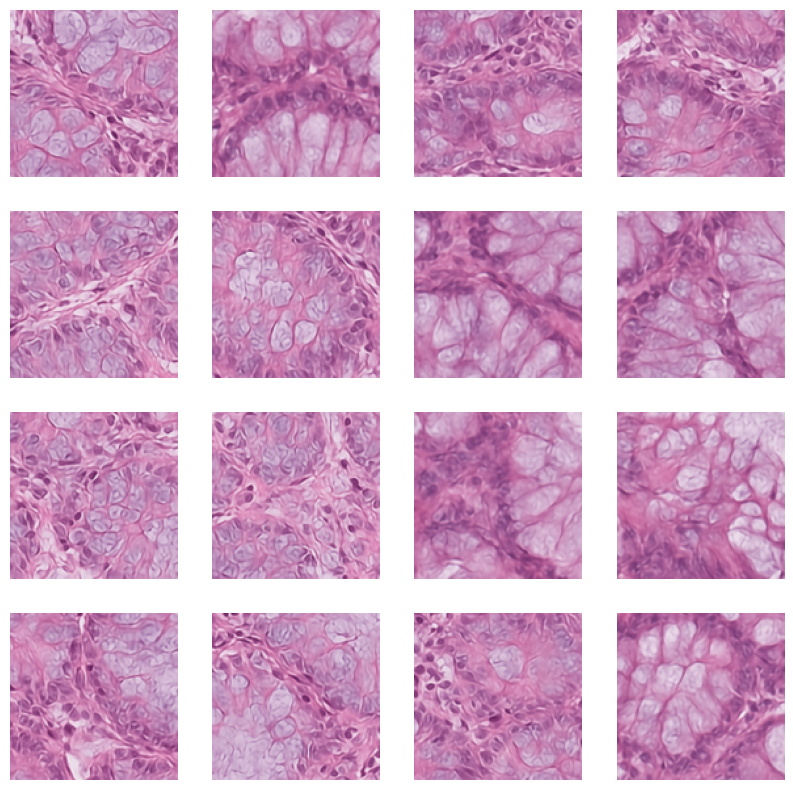

In [8]:
imgs = model.generate_images(num_images=16)

imgs = (imgs + 1)/2

plt.figure(figsize=(10,10))

for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(np.clip(imgs[i],0,1))
    plt.axis("off")

plt.show()

In [9]:
import shutil
import os

# 1. Setup the paths
folder_to_zip = "/kaggle/working/synthetic_data/NORM"
output_zip_name = "/kaggle/working/synthetic_NORM_images"

# 2. Compress the folder
print(f"Compressing images from {folder_to_zip}...")
shutil.make_archive(output_zip_name, 'zip', folder_to_zip)

print(f"file is ready: {output_zip_name}.zip")

Compressing images from /kaggle/working/synthetic_data/NORM...
file is ready: /kaggle/working/synthetic_NORM_images.zip
